In [1]:
# DSI visualization module lecture 5
# originally recorded June 15, 2026
# watching recording on June 17
# Robert Lu



plots - rational, moral, emotional appeal

rational - give the facts, numbers

moral - 

emotion - invoking emotion

for advocacy - present the facts, but also represent the facts subjectively using metaphor, allegory, analogy

what data is shown and not shown? what do we see, what don't we see? what/who is missing and how can we represent things more responsibly?





In [2]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests

In [3]:
# load example dataset, tips at restaurant

tips = sns.load_dataset("tips")
print(tips)

     total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]


In [19]:
tips["day"].value_counts()

day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64

[Text(0.5, 1.0, 'Tips vs. Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

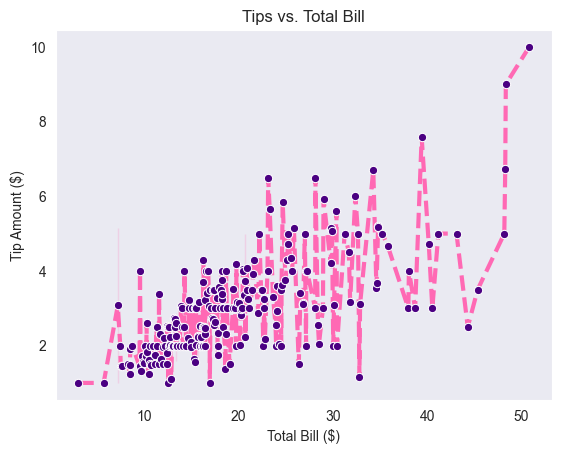

In [ ]:
# make a simple line plot
# sns and plt share basic functionality

# can set plot style
sns.set_style("dark")

# need to specify dataframe with data, then columns for x and y data
# assign graph as a variable to add stuff to it later
# the line below just makes the plot while assigning the variable
tipgraph = sns.lineplot(data=tips, x="total_bill", y="tip",
    color="hotpink", linestyle="--", linewidth=3,
    marker="o", markerfacecolor="indigo")

tipgraph.set(title="Tips vs. Total Bill", xlabel="Total Bill ($)", ylabel="Tip Amount ($)")


[Text(0.5, 1.0, 'Tips vs. Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

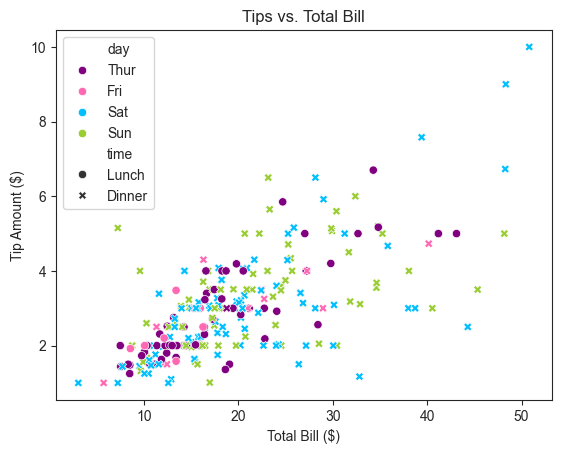

In [ ]:
# where does sns have an advantage over plt?
# for scatter, can easily represent multiple variables with different elements
# as we see, its really easy to split the data into different groups and plot them
# sns automatically creates these multiple scatter plots and creates the legend

# can set plot style
sns.set_style("ticks")

# need to specify dataframe with data, then columns for x and y data
# assign graph as a variable to add stuff to it later
# the line below just makes the plot while assigning the variable
tipgraph = sns.scatterplot(data=tips, x="total_bill", y="tip",
    style="time", # set different marker shape for data points based on time
    hue="day", # color points based on day categories
    palette=["purple", "hotpink", "deepskyblue", "yellowgreen"], # use these colors for different day categories
    # there is a default color palette too if you don't specify a palette
    )

tipgraph.set(title="Tips vs. Total Bill", xlabel="Total Bill ($)", ylabel="Tip Amount ($)")

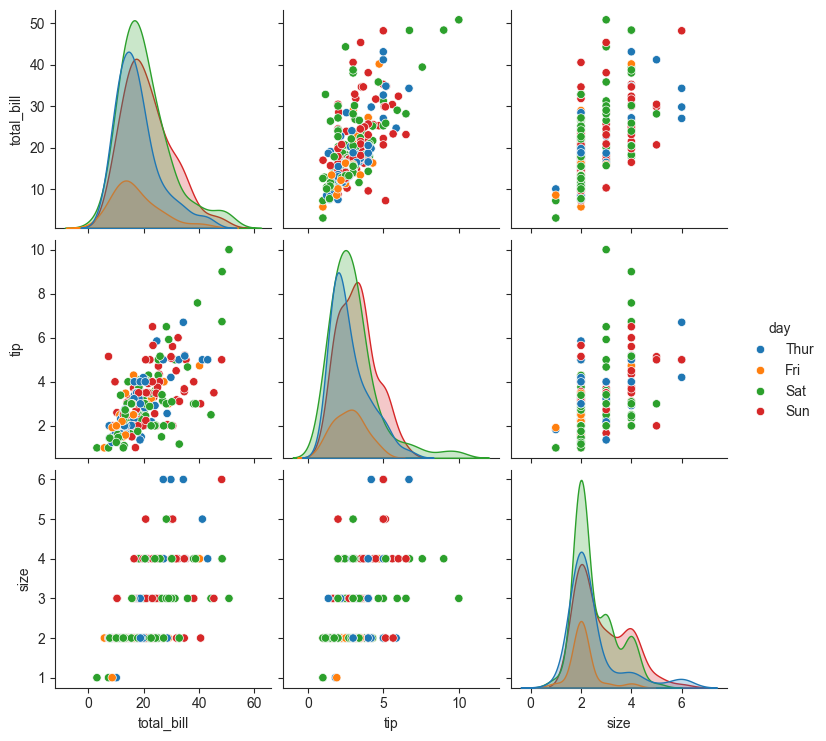

In [29]:
# pairplot is used to compare distributions of numeric variables
# this is like scatter_matrix

# adding hue="day" changed the plot a lot
sns.pairplot(data=tips,
    hue="day")

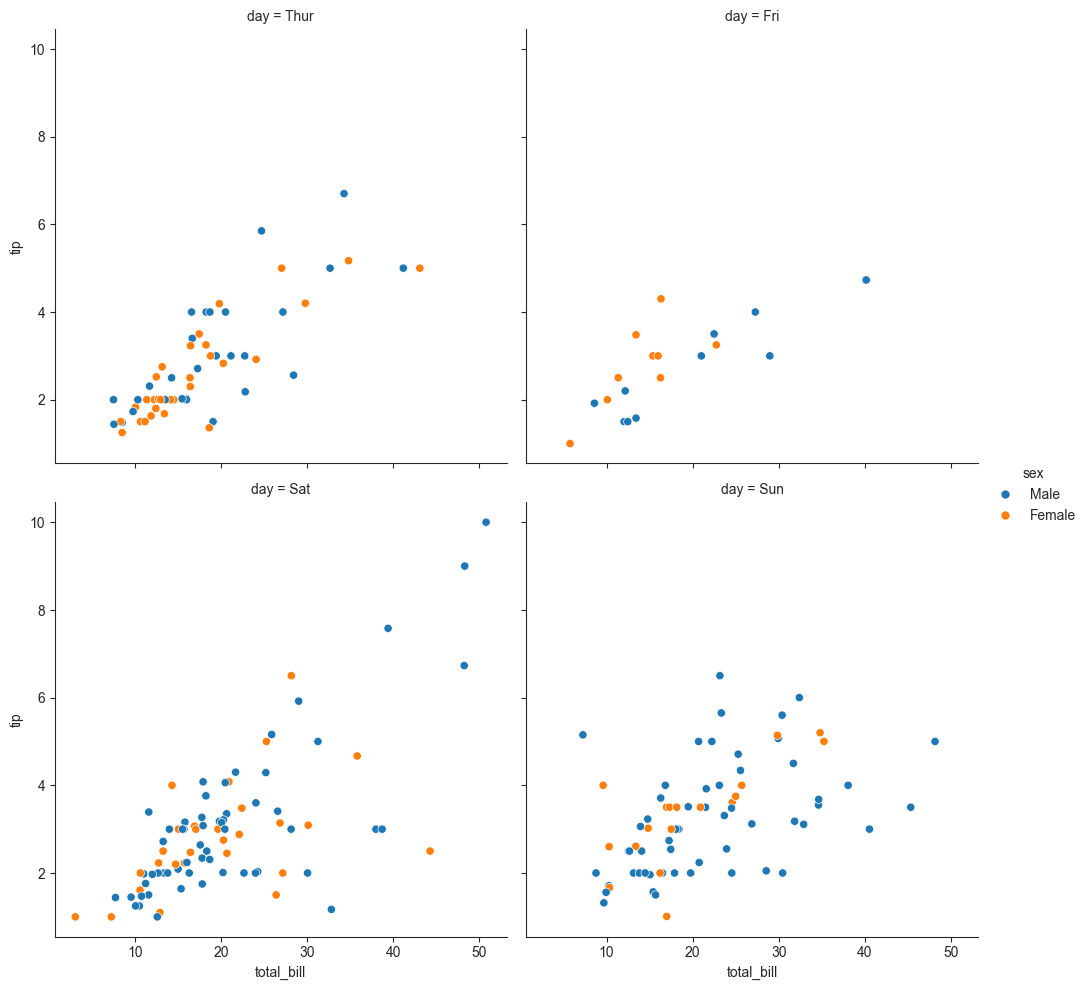

In [30]:
# relplot, create multi panel scatter plot

daysplot = sns.relplot(data=tips, x="total_bill", y="tip",
    hue="sex",
    col="day",
    kind="scatter",
    col_wrap=2)

student evaluations are more biased against female instructors


In [ ]:
# try creating plots using plotly
# plots are interactive to a degree by default, can pan, zoom

import plotly.graph_objects as go

x1 = np.array(["Luffy", "Zoro", "Nami", "Usopp", "Sanji"])
y1 = np.array([110, 180, 240, 99, 220])

# create a blank figure object
graph = go.Figure()

# add a bar plot
graph.add_trace(go.Bar(x=x1, y=y1))

# update layout to include titles
graph.update_layout(title="Pirate Scores",
    xaxis_title="Pirates",
    yaxis_title="Score")



# can export graph as html format to embed into webpages
#graph.write_html("./pirategraph.html")
# now the plot won't be displayed, instead, it's saved

In [ ]:
# creating a scatter plot

graph = go.Figure()

graph.add_trace(go.Scatter(x=x1, y=y1, mode="markers", # marker, want points for a scatter plot. theres diff modes
    marker=dict(size=15, color="hotpink", opacity=0.7, # set other params. not exactly a traditional python dictionary?
        line=dict(width=5, color="purple")) # point outline
    ))

graph.update_layout(title="Interactive Pirate Plot",
    xaxis_title="Pirates",
    yaxis_title="Scores",
    width=500, height=500) # figure size 

In [ ]:
# qualitative visualizations.
# wordcloud

from wordcloud import WordCloud

df = pd.read_csv("https://raw.githubusercontent.com/prasertcbs/basic-dataset/master/movie_quotes.csv",
    on_bad_lines="skip")

df

,quote,movie,type,year
0,"Do, or do not. There is no try.",Star Wars: Episode V - The Empire Strikes Back,movie,1890
1,Listen to them. Children of the night. What mu...,Dracula,movie,1931
2,It's alive! It's alive!,Frankenstein,movie,1931
3,"Oh, no, it wasn't the airplanes. It was Beauty...",King Kong,movie,1933
4,"Magic Mirror on the wall, who is the fairest o...",Snow White and the Seven Dwarves,movie,1937
...,...,...,...,...
727,I didn't know if you were lost. Stick with me....,Us,movie,2019
728,This guy's awesome! He's holding his own while...,Dragon Ball Super: Broly,movie,2019
729,"Murder is murder, it don’t matter who you are.",Black and Blue,movie,2019
730,You know what a lion is? A lion is a strong an...,Between Two Ferns: The Movie,movie,2019


In [48]:
# combine all quotes into a string
# join text from the quote column

text = " ".join(each for each in df.quote)
text

'Do, or do not. There is no try. Listen to them. Children of the night. What music they make. It\'s alive! It\'s alive! Oh, no, it wasn\'t the airplanes. It was Beauty killed the Beast. Magic Mirror on the wall, who is the fairest one of all? Elementary, my dear Watson. I\'ll get you, my pretty, and your little dog, too! After all, tomorrow is another day! Frankly, my dear, I don\'t give a damn. Toto, I\'ve got a feeling we\'re not in Kansas anymore. There\'s no place like home. As God is my witness, I\'ll never be hungry again. It\'s gone forever, that funny young, lost look I loved won\'t ever come back. I killed that when I told you about Rebecca. It\'s gone. In a few hours, you\'ve grown so much older. Here\'s looking at you, kid. Play it, Sam. Play \'As Time Goes By. We\'ll always have Paris. Round up the usual suspects. This is the beginning of a beautiful friendship. When it comes to women, you’re a true democrat. I am big! It\'s the pictures that got small. Nobody ever lies abo

In [54]:
# generate wordcloud image
# automatically calculates the number of each word
wordcloud = WordCloud(background_color="white", colormap="inferno").generate(text)

wordcloud

(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

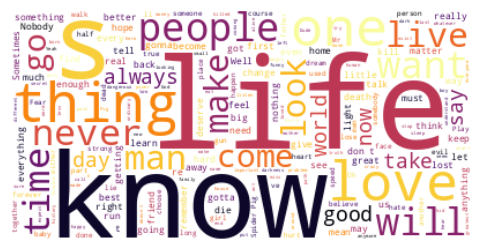

In [55]:
# show the image using mpl
fig, ax = plt.subplots(figsize=(7, 3))
ax.imshow(wordcloud, interpolation="bilinear")
ax.axis("off")

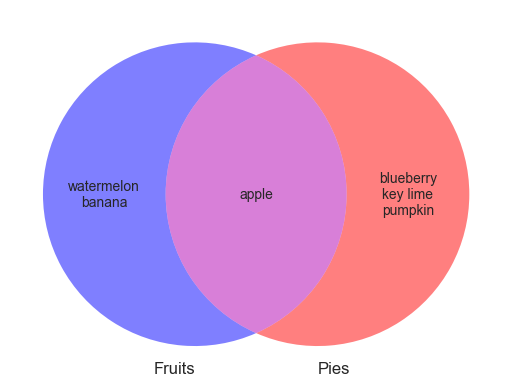

In [63]:
# venn diagrams

from matplotlib_venn import venn2, venn2_circles, venn2_unweighted

# define sets
A = set(["apple", "banana", "watermelon"])
B = set(["pumpkin", "blueberry", "apple", "key lime"])

diagram = venn2_unweighted([A, B], 
    set_labels=("Fruits", "Pies"),
    set_colors=("blue", "red"),
    alpha=0.5)

# diagram shows counts of number of elements in the sets by defaults
# modify diagram to show text, values within the sets
diagram.get_label_by_id("10").set_text("\n".join(A - B))
diagram.get_label_by_id("11").set_text("\n".join(A & B))
diagram.get_label_by_id("01").set_text("\n".join(B - A))

plt.show()